# Using SGU wells

This notebook demonstrates the use of the python package `sgu-client` and how to integrate with `gwrefpy`. The package is installed along with `gwrefpy` if recommended add-ons are included: `pip install "gwrefpy[recommended]"`

The Geological Survey of Sweden (SGU) serves an API for their groundwater monitoring network. A Python implementation of an API client has been developed in [`sgu-client`](https://github.com/officialankan/sgu-client) which makes getting observed groundwater levels from SGU into Python a breeze. 



```{note}
The `sgu-client` package is not affiliated with, supported or endorsed by SGU.
```

In [1]:
import gwrefpy as gr
from sgu_client import SGUClient
import warnings

warnings.filterwarnings("ignore")
gr.set_log_level("ERROR")

Log level set to ERROR


## Getting observed groundwater levels

This basic example will show how to fetch observed groundwater levels. For more options, please refer to [these docs](https://github.com/officialankan/sgu-client?tab=readme-ov-file#observed-groundwater-levels).

Below, we wrangle the data in two steps:

1. remove the UTC timezone from the fetched timeseries to achieve compatibility with the example model we will load later,
2. resample to daily medians to align the frequency with that of the example model we will load later

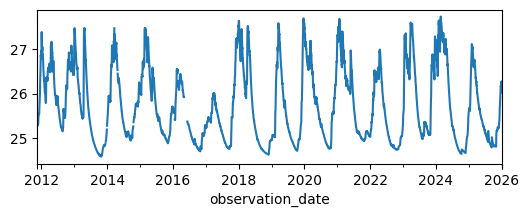

In [2]:
with SGUClient() as client:
    lagga_levels = client.levels.observed.get_measurements_by_name("95_2").to_series()

lagga_levels.index = lagga_levels.index.tz_convert(None) 
lagga_levels = lagga_levels.resample("1D").median()

_ = lagga_levels.plot(figsize=(6, 2))

## Inserting as a reference well in a `Model`

For this basic demonstration, we will load a tutorial model and add our newly fetched SGU well as a reference well.

In [3]:
model = gr.Model("deviation_example.gwref")
model.wells_summary()

,name,well_type,data_points,start_date,end_date,mean_level,latest_value,latest_date,latitude,longitude,elevation,best_fit_ref_well,best_rmse,num_fits,avg_rmse
0,19W110U,observation,2824,2018-01-01,2025-09-24,25.657419,24.949029,2025-09-24,None,None,None,None,None,NaN,NaN
1,19W100U,reference,2824,2018-01-01,2025-09-24,25.757644,24.873000,2025-09-24,None,None,None,NaN,NaN,0.0,None


In [4]:
well_object = gr.Well("95_2", is_reference=True, timeseries=lagga_levels)
model.add_well(well_object)

model.fit("19W110U", "95_2", offset="0D")  # both are sampled daily

2026-01-08 21:28:04,642 - gwrefpy.methods.linregressfit - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:04,643 - gwrefpy.methods.linregressfit - WARNING - tmax is None, setting to max common time of both wells


Statistic,Value,Description
RMSE,0.3025,Root Mean Square Error
R²,0.8736,Coefficient of Determination
R-value,0.9346,Correlation Coefficient
Slope,0.9033,Linear Regression Slope
Intercept,2.3905,Linear Regression Intercept
P-value,0.0000,Statistical Significance
N,2824,Number of Data Points
Std Error,0.3026,Standard Error
Confidence,95.0%,Confidence Level


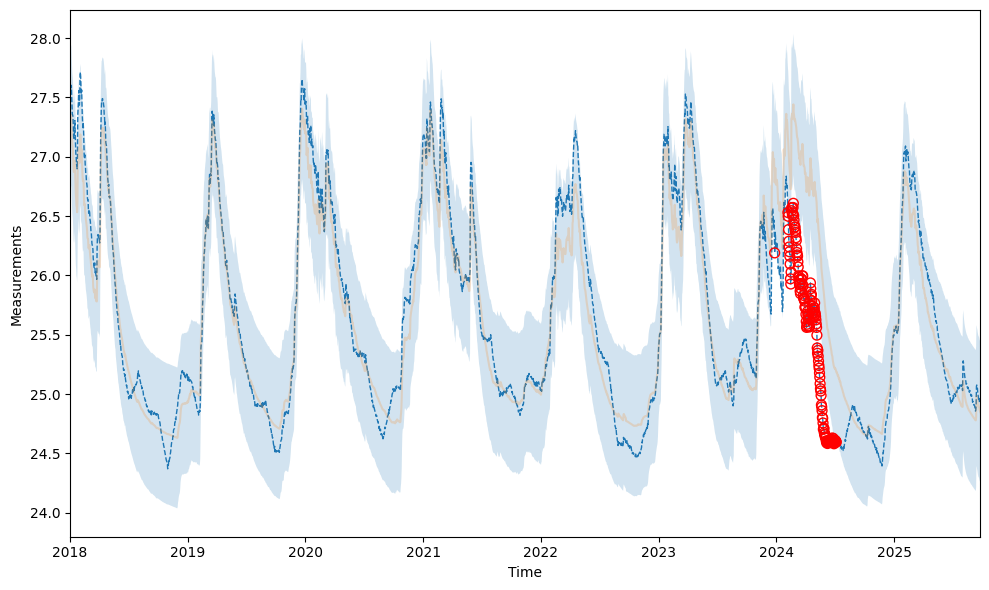

In [5]:
_ = model.plot_fits()

## Fitting to modeled groundwater levels

SGU serves an API for accessing modeled groundwater levels. Let's explore how we can integrate it with `gwrefpy`. 

More examples on fetching modeled groundwater levels can be found [here](https://github.com/officialankan/sgu-client?tab=readme-ov-file#modeled-groundwater-levels).

Below, we first get the metadata for the monitoring well *4_3* to retrieve its coordinates. We use that to get modeled groundwater levels at the site. Lastly, we get the observed levels which we will need for the fitting.

```{note}
The example below assumes we are interested in modeled **minor resources** (i.e. shallow or fast responding groundwater systems). For real-world applications, users should familiarize themselves with SGU's modeling methodology and the associated uncertainties of the modeled groundwater levels.
```

In [6]:
with SGUClient() as client:
    station = client.levels.observed.get_station_by_name("4_3")
    lon, lat = station.geometry.coordinates

    modeled = client.levels.modeled.get_levels_by_coords(lat, lon).to_series()
    observed = client.levels.observed.get_measurements_by_name("4_3").to_series()

# ensure daily data for compatability with modeled levels
observed = observed.resample("1D").median()
observed.index = observed.index.tz_convert(None)  # remove tz-info

# force modeled to float dtype
modeled = modeled.astype(float)

Below, we create a model and add the observed levels as an observation well and the modeled levels as a reference well.

In [7]:
model = gr.Model("modeled ref test")

model.add_well([
    gr.Well("obs", False, observed),
    gr.Well("ref", True, modeled)
])
model.wells_summary()

,name,well_type,data_points,start_date,end_date,mean_level,latest_value,latest_date,latitude,longitude,elevation,best_fit_ref_well,best_rmse,num_fits,avg_rmse
0,obs,observation,20123,1970-12-05,2026-01-07,150.006587,149.7,2026-01-07,None,None,None,None,None,NaN,NaN
1,ref,reference,23745,1961-01-01,2026-01-04,49.698126,39.0,2026-01-04,None,None,None,NaN,NaN,0.0,None


We then perform a fit between the two with two polynomial methods with varying degree. I suspect that the observation well has been affected by a storm in 2005, but this should not be reflected in the modeled levels which do not take such an event into account.

In [8]:
from itertools import product

for n, poly in product(
    range(1, 10), ("npolyfit", "chebyshev")
):
    model.fit(
        "obs",
        "ref",
        offset="0D",
        method=poly,
        degree=n,
        tmax="2004"
    )

2026-01-08 21:28:07,424 - gwrefpy.methods.npolyfit - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,439 - gwrefpy.methods.chebyshev - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,452 - gwrefpy.methods.npolyfit - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,465 - gwrefpy.methods.chebyshev - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,477 - gwrefpy.methods.npolyfit - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,490 - gwrefpy.methods.chebyshev - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,501 - gwrefpy.methods.npolyfit - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,514 - gwrefpy.methods.chebyshev - WARNING - tmin is None, setting to min common time of both wells
2026-01-08 21:28:07,527 - gwrefpy.methods.npolyfit -

Let's keep only the best fit and plot.

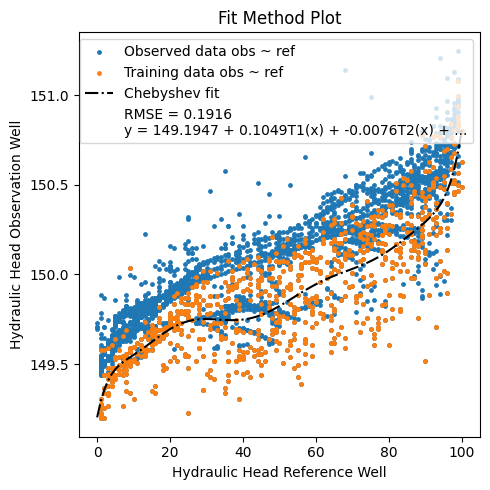

In [9]:
model.remove_fits_by_n("obs", 1)
_ = model.plot_fitmethod()

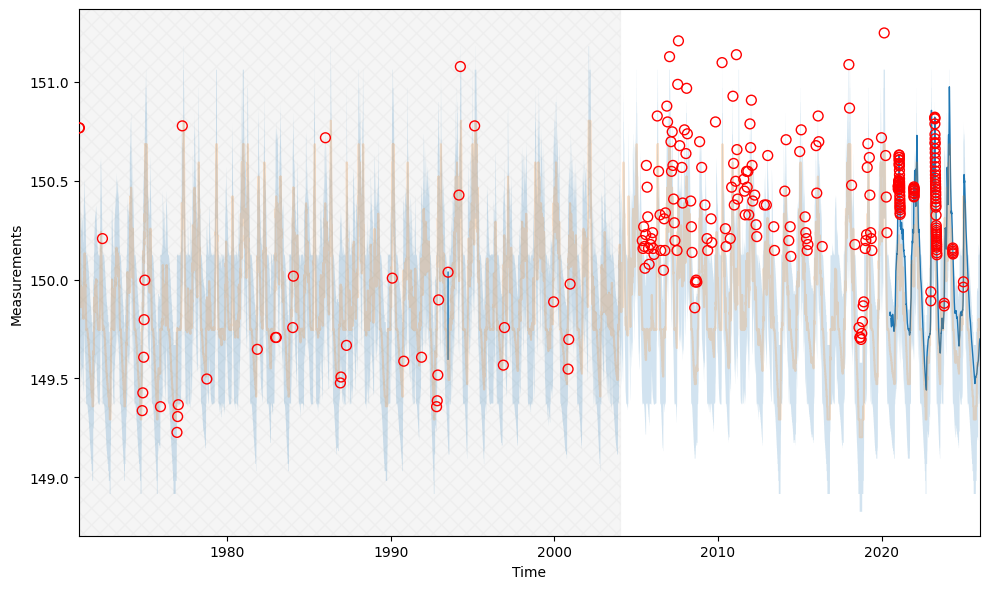

In [10]:
_ = model.plot_fits(show_initiation_period=True)

Looks like the number of outliers greatly increase after 2005?

This concludes this notebook for integrating `gwrefpy` and `sgu-client`. Workflows associated to this technique will most likely benefit from reading our tutorial on how to use `gwrefpy` with [live data](https://sgfsweden.github.io/gwrefpy/tutorials/livedata.html). 

Happy fitting and big thanks to SGU for their excellent monitoring network!